# Projet IPO — Notebook final unifié

Ce notebook regroupe les analyses des quatre hypothèses (H1, H2, H3, H4) sur **un seul DataFrame de référence** appelé `df_final`. Toutes les statistiques descriptives, tous les tests et tous les graphiques utilisent ce DataFrame, à l'exception de deux sous-ensembles documentés explicitement (filtre underpricing pour H2, dropna `ret_30d` pour H3).

**Échantillon de référence** : 407 IPO américaines sur la période 2019-2024, après application des filtres méthodologiques du livrable 2 (exclusion SPAC, direct listings, IPO < 50 M$, prix d'offre < 5 $).

- Cohorte 2019-2021 (taux bas) : 271 IPO
- Cohorte 2022-2024 (taux élevés) : 136 IPO

**Référence des rendements** : tous les rendements (H3 et H4) sont calculés depuis le prix de clôture du **premier jour de cotation (J0)**, soit la base `cum_return` du fichier `daily_returns_cache.csv`. Cette base est utilisée à la fois pour les boxplots et pour les courbes de performance, ce qui garantit la cohérence parfaite entre les deux types de graphique.

Tous les graphiques affichent les valeurs (médianes, moyennes, N, quartiles) directement sur la figure pour faciliter la lecture.


## 1. Imports et paramètres

In [3]:
# Bibliothèques utilisées
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf

# Style sobre, fond blanc
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# Couleurs cohérentes pour les deux cohortes
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}

# Dossier où l'on enregistre les graphiques
IMG_DIR = Path("images_finales")
IMG_DIR.mkdir(exist_ok=True)

SEED = 42


## 2. Construction du DataFrame de référence `df_final`

On charge `dataset_3_.xlsx` et on applique les filtres méthodologiques (déjà présents dans le dataset, ré-appliqués ici en garde-fou).

In [4]:
# Chargement du dataset principal
df_brut = pd.read_excel("data/dataset.xlsx")

# Construction de df_final
df_final = df_brut.copy()
df_final["year"] = pd.to_numeric(df_final["year"], errors="coerce")
df_final = df_final[df_final["year"].between(2019, 2024)].copy()

# Cohorte 2019-2021 (taux bas) vs 2022-2024 (taux élevés)
df_final["cohort"] = np.where(
    df_final["year"].between(2019, 2021),
    "2019-2021",
    "2022-2024"
)

# Filtres taille et prix d'offre
df_final["Size_Million"] = pd.to_numeric(df_final["Size_Million"], errors="coerce")
df_final["OfferPrice"] = pd.to_numeric(df_final["OfferPrice"], errors="coerce")
df_final = df_final[(df_final["Size_Million"].isna()) | (df_final["Size_Million"] >= 50)]
df_final = df_final[(df_final["OfferPrice"].isna()) | (df_final["OfferPrice"] > 5)]

# Conversion numérique
df_final["underpricing"] = pd.to_numeric(df_final["underpricing"], errors="coerce")
df_final["ret_30d"] = pd.to_numeric(df_final["ret_30d"], errors="coerce")
df_final["ret_12m"] = pd.to_numeric(df_final["ret_12m"], errors="coerce")
df_final["revenue_ltm"] = pd.to_numeric(df_final["revenue_ltm"], errors="coerce")
df_final["fed_rate"] = pd.to_numeric(df_final["fed_rate"], errors="coerce")

df_final = df_final.reset_index(drop=True)

print(f"df_final : {df_final.shape[0]} lignes, {df_final.shape[1]} colonnes")
print()
print("Répartition par cohorte :")
print(df_final["cohort"].value_counts().sort_index())
print()
print("Répartition par année :")
print(df_final["year"].value_counts().sort_index())


df_final : 407 lignes, 25 colonnes

Répartition par cohorte :
cohort
2019-2021    271
2022-2024    136
Name: count, dtype: int64

Répartition par année :
year
2019     71
2020     96
2021    104
2022     18
2023     32
2024     86
Name: count, dtype: int64


### 2.1 Chargement des prix journaliers

Le fichier `daily_returns_cache.csv` contient l'évolution journalière du rendement cumulé (`cum_return`) de chaque ticker depuis le prix de clôture du premier jour de cotation. On filtre ce fichier sur les tickers de `df_final` pour garantir la cohérence des graphiques.

À partir de ces données, on **recalcule** les rendements à 30 jours et 12 mois sur la même base (clôture J0) pour les utiliser dans tous les graphiques. Cette approche garantit que les boxplots et les courbes de performance utilisent exactement les mêmes valeurs.

In [5]:
# Chargement des prix journaliers
prix_journaliers = pd.read_csv("data/daily_returns_cache.csv")

# Le fichier contient déjà 'cohort' et 'year' : on les supprime pour éviter les conflits
# avec les colonnes de df_final lors du merge
prix_journaliers = prix_journaliers.drop(columns=["cohort", "year"])

# On filtre sur les tickers de df_final uniquement
prix_journaliers = prix_journaliers[prix_journaliers["ticker"].isin(df_final["ticker"])].copy()

# On ajoute la cohorte par jointure avec df_final
prix_journaliers = prix_journaliers.merge(
    df_final[["ticker", "cohort"]], on="ticker", how="left"
)

print(f"Tickers de df_final avec prix journaliers : {prix_journaliers['ticker'].nunique()}")
manquants = set(df_final["ticker"]) - set(prix_journaliers["ticker"])
if manquants:
    print(f"Ticker absent du fichier de prix : {manquants}")


Tickers de df_final avec prix journaliers : 406
Ticker absent du fichier de prix : {'HCWB'}


In [6]:
# Rendements depuis cum_return (déjà calculé depuis close J0 dans le fichier)
ret_30j_recalc = (
    prix_journaliers[prix_journaliers["trading_day"] == 21]
    .set_index("ticker")["cum_return"]
)
ret_12m_recalc = (
    prix_journaliers[prix_journaliers["trading_day"] == 252]
    .set_index("ticker")["cum_return"]
)

# Mapping vers df_final
df_final["ret_30j_calc"] = df_final["ticker"].map(ret_30j_recalc)
df_final["ret_12m_calc"] = df_final["ticker"].map(ret_12m_recalc)

### 2.2 Fonctions utilitaires

In [7]:
def bootstrap_ic(x, statistique="moyenne", n_boot=5000, seed=42):
    """Renvoie (statistique observée, borne basse IC95, borne haute IC95) par bootstrap."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    echantillons = x[idx]
    if statistique == "moyenne":
        boot = echantillons.mean(axis=1)
        obs = float(x.mean())
    else:
        boot = np.median(echantillons, axis=1)
        obs = float(np.median(x))
    return obs, float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


def annoter_boxplot(ax, donnees_par_cohorte, format_pct=False):
    """Annote chaque boxplot avec médiane, Q1, Q3 et N."""
    ordre = list(donnees_par_cohorte.keys())
    for i, cohorte in enumerate(ordre):
        s = donnees_par_cohorte[cohorte]
        med = s.median()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        n = len(s)
        f = lambda v: f"{v*100:.1f}%" if format_pct else f"{v:.2f}"
        # Médiane à droite du boxplot
        ax.annotate(f"méd = {f(med)}", xy=(i + 0.32, med),
                    fontsize=9, color="black", va="center")
        ax.annotate(f"Q1 = {f(q1)}", xy=(i + 0.32, q1),
                    fontsize=8, color="dimgray", va="center")
        ax.annotate(f"Q3 = {f(q3)}", xy=(i + 0.32, q3),
                    fontsize=8, color="dimgray", va="center")
        # N en bas
        ax.text(i, ax.get_ylim()[0],
                f"N = {n}", ha="center", va="bottom",
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.8))


## 3. Hypothèse H1 — Sélection des entreprises

**Hypothèse** : les entreprises introduites en 2022-2024 présentent des fondamentaux plus solides que celles de 2019-2021, en particulier une part plus élevée d'entreprises rentables.

**Variables** : `revenue_ltm` (chiffre d'affaires sur 12 mois en M$) et `profitable` (1/0/NaN).

**Méthode** : statistiques descriptives par cohorte, IC bootstrap sur la médiane du CA, test de Mann-Whitney sur la distribution du CA, Z-test de proportion sur la rentabilité.

**Précision** : la colonne `profitable` contient 43 valeurs manquantes, toutes dans la cohorte 2019-2021. Les calculs ci-dessous excluent explicitement ces NaN. Une version antérieure les comptait silencieusement comme « non rentables » (donnant 22,5 % au lieu de 26,8 %).

In [8]:
# H1 — Statistiques descriptives par cohorte sur df_final
resultats_h1 = []
for cohorte in ["2019-2021", "2022-2024"]:
    sub = df_final[df_final["cohort"] == cohorte]
    rev = sub["revenue_ltm"].dropna()  # tous CA renseignés (y compris 0)
    rev_pos = rev[rev > 0]              # CA strictement positifs
    prof = sub["profitable"].dropna()   # exclut explicitement les NaN
    rev_med, rev_lo, rev_hi = bootstrap_ic(rev, "médiane")
    rev_pos_med, rev_pos_lo, rev_pos_hi = bootstrap_ic(rev_pos, "médiane")
    resultats_h1.append({
        "Cohorte": cohorte,
        "N IPO": len(sub),
        "N CA renseigné": len(rev),
        "dont CA = 0": int((rev == 0).sum()),
        "Médiane CA tous (M$)": round(rev_med, 2),
        "Médiane CA > 0 (M$)": round(rev_pos_med, 2),
        "N rentabilité connue": len(prof),
        "Part rentable (%)": round(prof.mean() * 100, 1),
    })

tableau_h1 = pd.DataFrame(resultats_h1)
print(tableau_h1.to_string(index=False))
print()
print("Lecture : selon le filtre retenu (avec ou sans les CA = 0), la conclusion sur H1 s'inverse.")
print("- Médiane sur tous les CA renseignés : 2019-2021 > 2022-2024 → contre H1.")
print("- Médiane sur les CA > 0 uniquement : 2019-2021 < 2022-2024 → pour H1.")
print("- La cohorte 2022-2024 contient 37 % d'entreprises sans CA (biotechs en phase clinique),")
print("  contre 9 % en 2019-2021. Ce profil bimodal est un trait distinctif de la période.")


  Cohorte  N IPO  N CA renseigné  dont CA = 0  Médiane CA tous (M$)  Médiane CA > 0 (M$)  N rentabilité connue  Part rentable (%)
2019-2021    271             228           20                134.25               157.08                   228               26.8
2022-2024    136             136           51                 18.87               515.20                   136               58.8

Lecture : selon le filtre retenu (avec ou sans les CA = 0), la conclusion sur H1 s'inverse.
- Médiane sur tous les CA renseignés : 2019-2021 > 2022-2024 → contre H1.
- Médiane sur les CA > 0 uniquement : 2019-2021 < 2022-2024 → pour H1.
- La cohorte 2022-2024 contient 37 % d'entreprises sans CA (biotechs en phase clinique),
  contre 9 % en 2019-2021. Ce profil bimodal est un trait distinctif de la période.


In [9]:
# H1 — Tests statistiques
ca_bas = df_final.loc[df_final["cohort"] == "2019-2021", "revenue_ltm"].dropna()
ca_eleve = df_final.loc[df_final["cohort"] == "2022-2024", "revenue_ltm"].dropna()
mw_h1 = stats.mannwhitneyu(ca_bas, ca_eleve, alternative="two-sided")
print(f"Mann-Whitney CA (bilatéral) : U = {mw_h1.statistic:.0f}, p-value = {mw_h1.pvalue:.4f}")

prof_bas = df_final.loc[df_final["cohort"] == "2019-2021", "profitable"].dropna()
prof_eleve = df_final.loc[df_final["cohort"] == "2022-2024", "profitable"].dropna()
succes = np.array([int(prof_eleve.sum()), int(prof_bas.sum())])
n_obs = np.array([len(prof_eleve), len(prof_bas)])
z_stat, z_pval = proportions_ztest(succes, n_obs, alternative="larger")
print(f"Z-test proportion (2022-2024 > 2019-2021) : Z = {z_stat:.3f}, p-value = {z_pval:.6f}")


Mann-Whitney CA (bilatéral) : U = 18060, p-value = 0.0083
Z-test proportion (2022-2024 > 2019-2021) : Z = 6.076, p-value = 0.000000


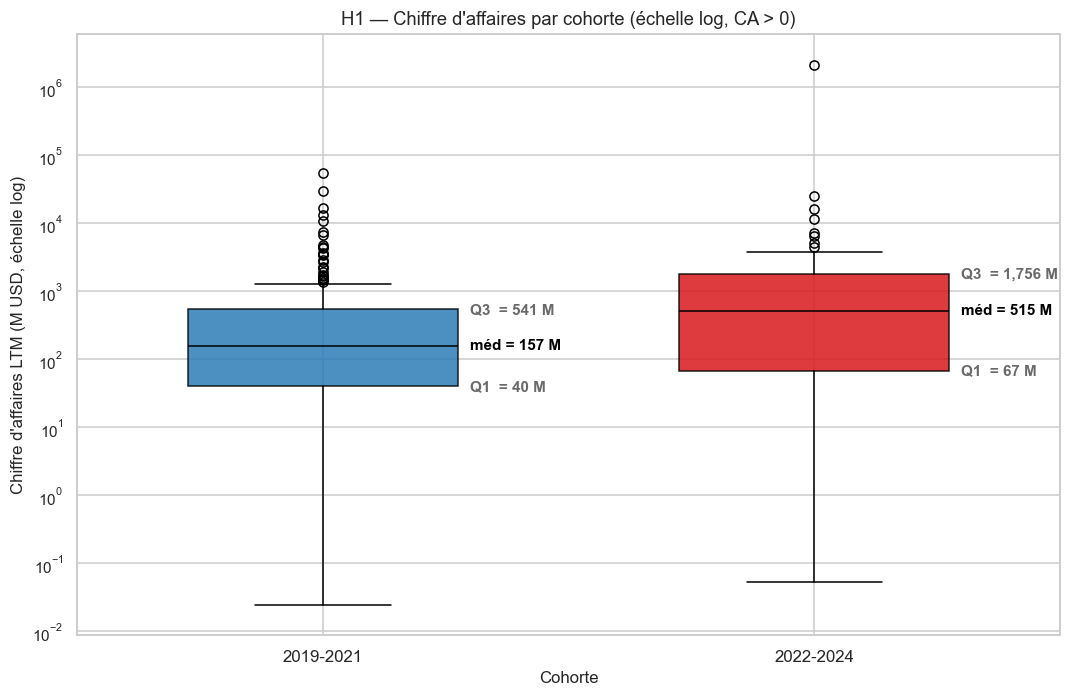

In [10]:
# H1 — Graphique 1 : boxplot du chiffre d'affaires (échelle log, CA > 0 uniquement)
sub = df_final.dropna(subset=["revenue_ltm"]).copy()
sub_pos = sub[sub["revenue_ltm"] > 0]

fig, ax = plt.subplots(figsize=(10, 6.5))

positions = [0, 1]  # espace plus large entre les deux boxplots
data_box = [
    sub_pos.loc[sub_pos["cohort"] == "2019-2021", "revenue_ltm"],
    sub_pos.loc[sub_pos["cohort"] == "2022-2024", "revenue_ltm"],
]

bp = ax.boxplot(
    data_box,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showfliers=True
)

for patch, color in zip(bp["boxes"], [COLORS["2019-2021"], COLORS["2022-2024"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_color("black")

ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(["2019-2021", "2022-2024"], fontsize=11)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Chiffre d'affaires LTM (M USD, échelle log)")
ax.set_title("H1 — Chiffre d'affaires par cohorte (échelle log, CA > 0)")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin * 0.9, ymax * 1.15)
ax.set_xlim(-0.8, 2.8)  # garde le vide au milieu visible

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = sub_pos.loc[sub_pos["cohort"] == cohorte, "revenue_ltm"]
    s_all = sub.loc[sub["cohort"] == cohorte, "revenue_ltm"]
    n_zero = int((s_all == 0).sum())
    med = s.median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)

    x = positions[i]
    ax.annotate(f"méd = {med:,.0f} M", xy=(x + 0.3, med),
                fontsize=10, color="black", va="center", fontweight="bold")
    ax.annotate(f"Q1  = {q1:,.0f} M", xy=(x + 0.3, q1),
                fontsize=10, color="dimgray", va="center", fontweight="bold")
    ax.annotate(f"Q3  = {q3:,.0f} M", xy=(x + 0.3, q3),
                fontsize=10, color="dimgray", va="center", fontweight="bold")
    # ax.hlines([q1, q3], x - 0.18, x + 0.45,
    #           colors="dimgray", linestyles="--", linewidth=1)

    # label = f"N = {n}\n(+ {n_zero} avec CA = 0\nnon visibles)" if n_zero > 0 else f"N = {n}"
    # ax.text(x, ymin * 1.05, label, ha="center", va="bottom",
    #         fontsize=9.5, fontweight="bold")

ax.set_xlim(-0.5, 1.5)  # réduit le vide à droite


plt.tight_layout()
plt.show()

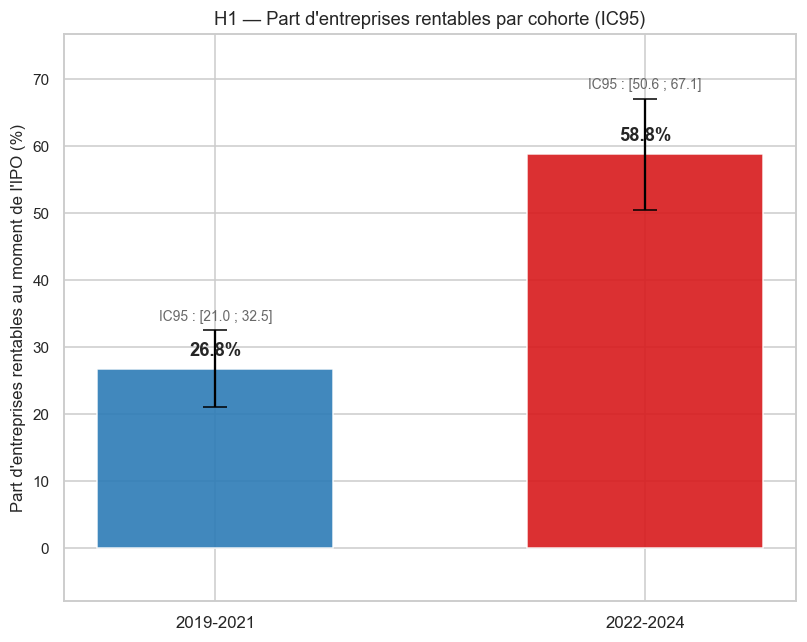

In [11]:
# H1 — Graphique 2 : part d'entreprises rentables avec IC à 95% (proportion binomiale)
fig, ax = plt.subplots(figsize=(7.5, 6))
parts, ic_bas, ic_haut, n_obs_list = [], [], [], []
for c in ["2019-2021", "2022-2024"]:
    s = df_final.loc[df_final["cohort"] == c, "profitable"].dropna()
    p = s.mean()
    n = len(s)
    se = np.sqrt(p * (1 - p) / n)
    parts.append(p * 100)
    ic_bas.append((p - 1.96 * se) * 100)
    ic_haut.append((p + 1.96 * se) * 100)
    n_obs_list.append(n)

x_pos = [0, 1]
ax.bar(x_pos, parts,
       color=[COLORS["2019-2021"], COLORS["2022-2024"]],
       width=0.55, alpha=0.9,
       yerr=[np.array(parts) - np.array(ic_bas),
             np.array(ic_haut) - np.array(parts)],
       capsize=8, error_kw={"ecolor": "black", "elinewidth": 1.5})
ax.set_xticks(x_pos)
ax.set_xticklabels(["2019-2021", "2022-2024"], fontsize=11)
ax.set_ylabel("Part d'entreprises rentables au moment de l'IPO (%)")
ax.set_title("H1 — Part d'entreprises rentables par cohorte (IC95)")
# On garde un peu de marge en bas pour les N et un peu plus en haut pour les annotations
ax.set_ylim(-8, max(parts) + 18)

# Annotations valeur + IC
for i, (p, lo, hi, n) in enumerate(zip(parts, ic_bas, ic_haut, n_obs_list)):
    ax.text(i, p + 2, f"{p:.1f}%", ha="center", fontsize=12, fontweight="bold")
    ax.text(i, hi + 1.5, f"IC95 : [{lo:.1f} ; {hi:.1f}]",
            ha="center", fontsize=9, color="dimgray")

# # Annotation N en bas, sous l'axe (en utilisant transform=ax.transData mais bien sous 0)
# for i, n in enumerate(n_obs_list):
#     ax.text(i, -5, f"N = {n}", ha="center", fontsize=10,
#             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85))

plt.tight_layout()
plt.savefig(IMG_DIR / "H1_part_rentable.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture H1** : la médiane du CA est plus élevée pour 2019-2021 (134 M$) que pour 2022-2024 (19 M$), ce qui ne va pas dans le sens attendu, et le test de Mann-Whitney détecte cette différence (p ≈ 0,008). En revanche, la part d'entreprises rentables est nettement plus élevée en 2022-2024 (58,8 % contre 26,8 %), avec un test de proportion très significatif. H1 est donc partiellement soutenue : la sélection en période de taux élevés se fait par la rentabilité, pas par la taille du CA.

## 4. Hypothèse H2 — Underpricing au premier jour

**Hypothèse** : l'underpricing est plus faible pour les IPO de 2022-2024.

**Variable** : underpricing = (close J0 − OfferPrice) / OfferPrice.

**Sous-ensemble** : on retire les valeurs aberrantes hors [-95 % ; 200 %] (44 obs : ex DUO 2019 affiche close J0 = 46 800 $ pour OfferPrice = 13 $, manifestement une erreur de scraping yfinance liée à un split). N = 363 (231 + 132).

In [12]:
# H2 — Sous-ensemble propre à H2 (filtre underpricing aberrant)
df_h2 = df_final[df_final["underpricing"].between(-0.95, 2.0)].copy()
df_h2 = df_h2.dropna(subset=["underpricing", "cohort"])

print(f"Échantillon H2 : {len(df_h2)} IPO (sur {len(df_final)} de df_final)")
print(df_h2["cohort"].value_counts().sort_index())


Échantillon H2 : 363 IPO (sur 407 de df_final)
cohort
2019-2021    231
2022-2024    132
Name: count, dtype: int64


In [13]:
# H2 — Statistiques descriptives par cohorte
resultats_h2 = []
for cohorte in ["2019-2021", "2022-2024"]:
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    moy, lo_m, hi_m = bootstrap_ic(s, "moyenne")
    med, lo_md, hi_md = bootstrap_ic(s, "médiane")
    resultats_h2.append({
        "Cohorte": cohorte,
        "N": len(s),
        "Moyenne (%)": round(moy * 100, 2),
        "IC95 moyenne (%)": f"[{lo_m*100:.2f} ; {hi_m*100:.2f}]",
        "Médiane (%)": round(med * 100, 2),
        "IC95 médiane (%)": f"[{lo_md*100:.2f} ; {hi_md*100:.2f}]",
        "Écart-type (%)": round(s.std() * 100, 2),
        "Q1 (%)": round(s.quantile(0.25) * 100, 2),
        "Q3 (%)": round(s.quantile(0.75) * 100, 2),
    })
tableau_h2 = pd.DataFrame(resultats_h2)
print(tableau_h2.to_string(index=False))


  Cohorte   N  Moyenne (%) IC95 moyenne (%)  Médiane (%) IC95 médiane (%)  Écart-type (%)  Q1 (%)  Q3 (%)
2019-2021 231        27.66  [22.29 ; 33.29]        22.21  [17.27 ; 26.88]           41.94    0.00   48.03
2022-2024 132         6.89   [2.31 ; 11.48]         0.56    [0.00 ; 5.49]           27.28   -2.02   14.29


In [14]:
# H2 — Tests statistiques
underpricing_bas = df_h2.loc[df_h2["cohort"] == "2019-2021", "underpricing"]
underpricing_eleve = df_h2.loc[df_h2["cohort"] == "2022-2024", "underpricing"]

mw = stats.mannwhitneyu(underpricing_bas, underpricing_eleve, alternative="greater")
print(f"Mann-Whitney unilatéral (2019-2021 > 2022-2024) : U = {mw.statistic:.0f}, p-value = {mw.pvalue:.6f}")

welch = stats.ttest_ind(underpricing_bas, underpricing_eleve, equal_var=False)
print(f"Welch sur les moyennes (bilatéral) : t = {welch.statistic:.3f}, p-value = {welch.pvalue:.6f}")


Mann-Whitney unilatéral (2019-2021 > 2022-2024) : U = 20338, p-value = 0.000000
Welch sur les moyennes (bilatéral) : t = 5.707, p-value = 0.000000


In [15]:
# H2 — Régression OLS comme outil complémentaire
df_ols = df_h2.copy()
df_ols["log_size"] = np.log(df_ols["Size_Million"].where(df_ols["Size_Million"] > 0))
df_ols["pe_backed_n"] = pd.to_numeric(df_ols["pe_backed"], errors="coerce")
df_ols = df_ols.dropna(subset=["underpricing", "fed_rate", "log_size", "pe_backed_n"])

modele = smf.ols("underpricing ~ fed_rate + log_size + pe_backed_n", data=df_ols).fit()
print(modele.summary().tables[1])
print(f"\nR² = {modele.rsquared:.3f}, R² ajusté = {modele.rsquared_adj:.3f}, N = {int(modele.nobs)}")


                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.1037      0.126     -0.825      0.410      -0.351       0.143
fed_rate       -0.0383      0.010     -3.999      0.000      -0.057      -0.019
log_size        0.0551      0.021      2.629      0.009       0.014       0.096
pe_backed_n     0.0968      0.065      1.495      0.136      -0.031       0.224

R² = 0.090, R² ajusté = 0.082, N = 363


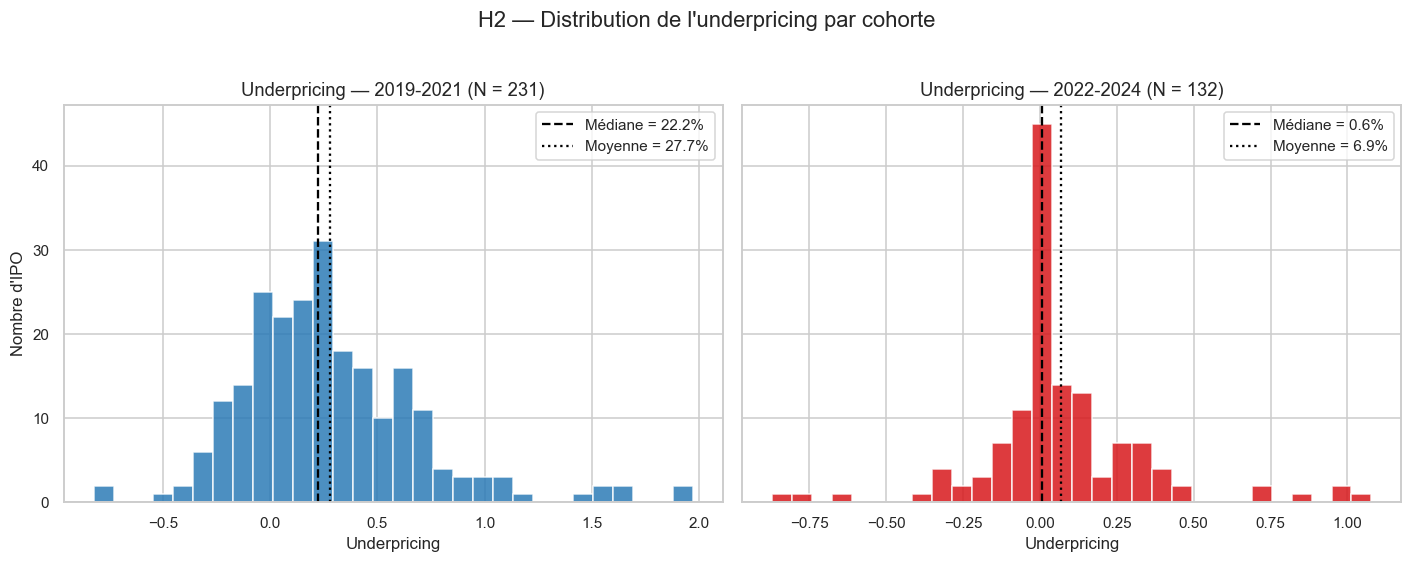

In [16]:
# H2 — Graphique 1 : distributions par cohorte avec médiane et moyenne tracées
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cohorte in zip(axes, ["2019-2021", "2022-2024"]):
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    ax.hist(s, bins=30, color=COLORS[cohorte], alpha=0.85, edgecolor="white")
    med, moy = s.median(), s.mean()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.5,
               label=f"Médiane = {med*100:.1f}%")
    ax.axvline(moy, color="black", linestyle=":", linewidth=1.5,
               label=f"Moyenne = {moy*100:.1f}%")
    ax.set_title(f"Underpricing — {cohorte} (N = {len(s)})")
    ax.set_xlabel("Underpricing")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Nombre d'IPO")
plt.suptitle("H2 — Distribution de l'underpricing par cohorte", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "H2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


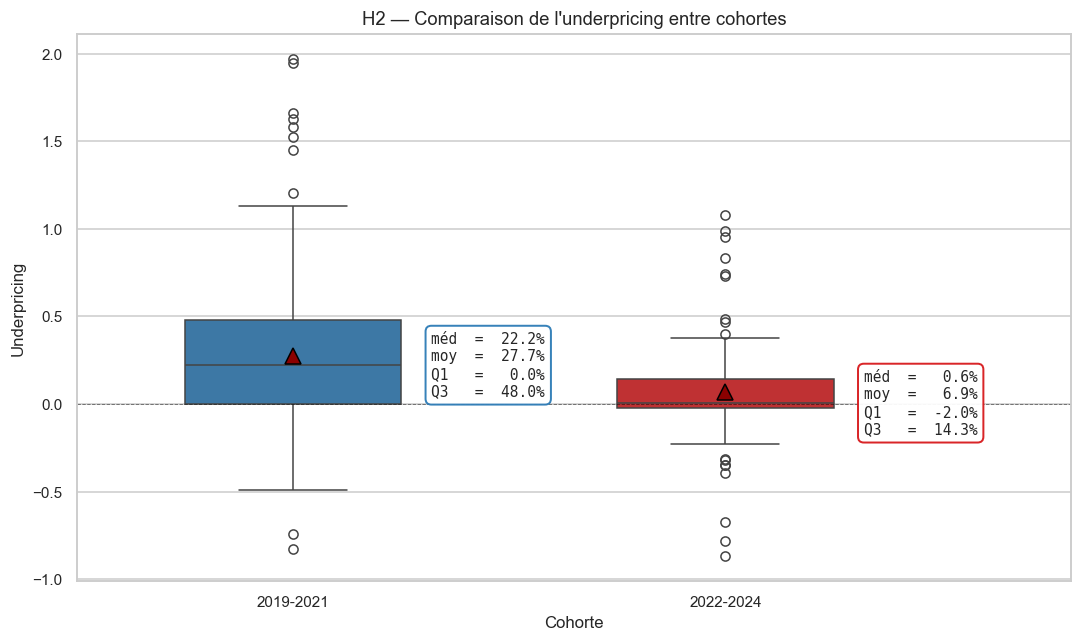

In [17]:
# H2 — Graphique 2 : boxplot avec encadrés stats
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_h2, x="cohort", y="underpricing",
    order=["2019-2021", "2022-2024"],
    palette=COLORS, ax=ax, width=0.5
)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Underpricing")
ax.set_title("H2 — Comparaison de l'underpricing entre cohortes")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    med, moy = s.median(), s.mean()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11,
            zorder=5, markeredgecolor="black")
    txt = (
           f"méd  = {med*100:5.1f}%\n"
           f"moy  = {moy*100:5.1f}%\n"
           f"Q1   = {q1*100:5.1f}%\n"
           f"Q3   = {q3*100:5.1f}%")
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      ec=COLORS[cohorte], lw=1.3, alpha=0.95))
ax.set_xlim(-0.5, 1.8)  # réduit le vide à droite

plt.tight_layout()
plt.savefig(IMG_DIR / "H2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


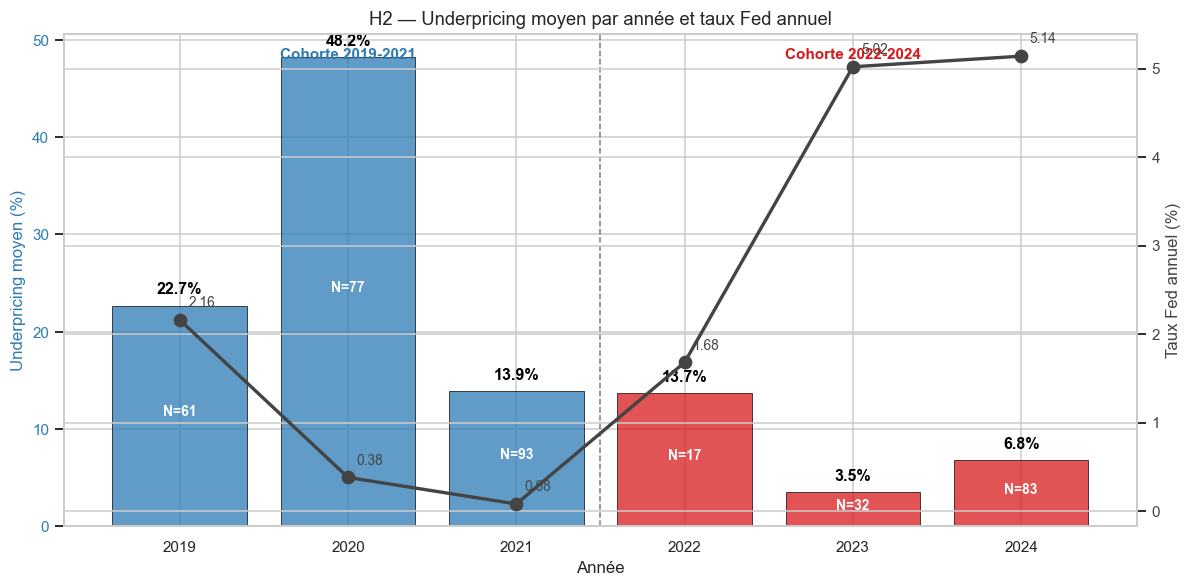

In [18]:
# H2 — Graphique 3 : underpricing moyen par année + taux Fed annuel
# Couleurs différenciées pour les deux cohortes
annees = sorted(df_h2["year"].unique())
underpricing_par_an = df_h2.groupby("year")["underpricing"].mean() * 100
n_par_an = df_h2.groupby("year")["underpricing"].count()
fed_par_an = df_final.groupby("year")["fed_rate"].first()

couleurs_barres = [COLORS["2019-2021"] if a <= 2021 else COLORS["2022-2024"]
                   for a in annees]

fig, ax1 = plt.subplots(figsize=(11, 5.5))
bars = ax1.bar(annees, underpricing_par_an.reindex(annees),
               color=couleurs_barres, alpha=0.75,
               edgecolor="black", linewidth=0.6,
               label="Underpricing moyen (%)")
ax1.set_xlabel("Année")
ax1.set_ylabel("Underpricing moyen (%)", color="#2C7BB6")
ax1.tick_params(axis="y", labelcolor="#2C7BB6")

# Annotations valeur et N
for an, val in underpricing_par_an.reindex(annees).items():
    n = n_par_an.get(an, 0)
    ax1.text(an, val + 1.2, f"{val:.1f}%", ha="center",
             fontsize=10.5, fontweight="bold", color="black")
    ax1.text(an, max(val/2, 1), f"N={n}", ha="center",
             fontsize=9, color="white", fontweight="bold")

# Marquer la frontière entre cohortes
ax1.axvline(2021.5, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax1.text(2020, ax1.get_ylim()[1] * 0.95, "Cohorte 2019-2021",
         fontsize=10, color=COLORS["2019-2021"], fontweight="bold", ha="center")
ax1.text(2023, ax1.get_ylim()[1] * 0.95, "Cohorte 2022-2024",
         fontsize=10, color=COLORS["2022-2024"], fontweight="bold", ha="center")

ax2 = ax1.twinx()
ax2.plot(annees, fed_par_an.reindex(annees), color="#444",
         marker="o", linewidth=2.2, markersize=8, label="Taux Fed (%)")
for an, val in fed_par_an.reindex(annees).items():
    ax2.text(an + 0.05, val + 0.15, f"{val:.2f}", fontsize=9, color="#444")
ax2.set_ylabel("Taux Fed annuel (%)", color="#444")
ax2.tick_params(axis="y", labelcolor="#444")

plt.title("H2 — Underpricing moyen par année et taux Fed annuel")
plt.tight_layout()
plt.savefig(IMG_DIR / "H2_underpricing_par_annee.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture H2** : la moyenne (27,7 % vs 6,9 %) et la médiane (22,2 % vs 0,6 %) chutent fortement entre les deux cohortes. Le test de Mann-Whitney rejette nettement l'égalité (p ≈ 0). La régression OLS confirme un coefficient négatif et significatif sur le taux Fed (-0,038, p ≈ 0,000) : une hausse d'un point de taux est associée à une baisse de l'underpricing d'environ 3,8 points de pourcentage. H2 est soutenue, à nuancer (taux annuel = approximation grossière, effet 2021, composition sectorielle).

## 5. Hypothèse H3 — Performance à 30 jours

**Hypothèse** : les IPO de 2022-2024 présentent une performance à 30 jours plus stable et moins volatile que celles de 2019-2021.

**Variable** : `ret_30j_calc` = (prix de clôture au jour de trading 21 − prix de clôture J0) / prix de clôture J0. Recalculée depuis `daily_returns_cache.csv` pour garantir la cohérence avec les courbes de performance.

**Méthode** : statistiques de dispersion descriptives, boxplot, courbe d'évolution moyenne et médiane des rendements jour par jour. Conformément au choix méthodologique du groupe, aucun test formel de comparaison de variance.

In [19]:
# H3 — Sous-ensemble (df_final + dropna ret_30j_calc)
df_h3 = df_final.dropna(subset=["ret_30j_calc"]).copy()
print(f"Échantillon H3 : {len(df_h3)} IPO")
print(df_h3["cohort"].value_counts().sort_index())
df_h3

Échantillon H3 : 406 IPO
cohort
2019-2021    270
2022-2024    136
Name: count, dtype: int64


,ticker,year,open_px,close_px,underpricing,ret_30d,ipo_size_m,fed_rate,sic,sector,...,ret_12m_flag,ipo_date,OfferPrice,Size_Million,Date,FilingUrl,ret_12m,ret_12m.1,ret_30j_calc,ret_12m_calc
0,PINS,2019,23.750000,24.400000,0.284211,0.000000,2068.850625,2.16,7370.0,Tech,...,ok,1970-01-01 01:00:25.569,19.0,1425.000000,2019-04-18T17:22:46-04:00,https://www.sec.gov/Archives/edgar/data/150629...,-0.284836,-0.284836,0.124211,-0.265263
1,REAL,2019,28.000000,28.900000,0.445000,-0.381315,550.765600,2.16,5900.0,Consumer,...,ok,1970-01-01 01:00:25.569,20.0,300.000000,2019-06-28T06:07:10-04:00,https://www.sec.gov/Archives/edgar/data/157322...,-0.536332,-0.536332,-0.102857,-0.521429
2,SNDL,2019,130.199997,84.800003,5.523077,0.031840,121.273485,2.16,2833.0,Industrials,...,ok,1970-01-01 01:00:25.569,13.0,143.000000,2019-08-01T11:12:51-04:00,https://www.sec.gov/Archives/edgar/data/176660...,-0.932311,-0.932311,-0.396313,-0.955914
3,PGNY,2019,13.500000,15.940000,0.226154,0.744668,67.140900,2.16,8090.0,Healthcare,...,ok,1970-01-01 01:00:25.569,13.0,130.000000,2019-10-25T16:44:36-04:00,https://www.sec.gov/Archives/edgar/data/155130...,0.753451,0.753451,0.902222,1.070370
4,SITM,2019,13.000000,13.000000,0.000000,0.961538,0.001300,2.16,3674.0,Industrials,...,ok,1970-01-01 01:00:25.569,13.0,55.900000,2019-11-21T16:55:16-05:00,https://www.sec.gov/Archives/edgar/data/145180...,5.213077,5.213077,0.620769,5.213077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,MRX,2024,18.907046,18.412554,-0.030918,0.053712,137.437208,5.14,6200.0,Finance,...,ok,1970-01-01 01:00:25.569,19.0,292.307685,2024-04-25T19:31:09-04:00,https://www.sec.gov/Archives/edgar/data/199746...,1.347062,1.347062,0.053846,1.285678
403,GUTS,2024,13.750000,12.850000,-0.143333,-0.513619,40.521250,5.14,3841.0,Industrials,...,ok,1970-01-01 01:00:25.569,15.0,109.999995,2024-02-02T16:18:22-05:00,https://www.sec.gov/Archives/edgar/data/157261...,-0.880545,-0.880545,-0.262545,-0.888364
404,IBAC,2024,9.960000,9.980000,-0.002000,-0.001002,0.026892,5.14,6770.0,Finance,...,ok,1970-01-01 01:00:25.569,10.0,100.000000,2024-03-27T17:28:06-04:00,https://www.sec.gov/Archives/edgar/data/199878...,0.038076,0.038076,0.001004,0.040161
405,DTSQ,2024,9.980000,9.970000,-0.003000,0.004012,2.194602,5.14,6770.0,Finance,...,ok,1970-01-01 01:00:25.569,10.0,60.000000,2024-07-26T08:56:04-04:00,https://www.sec.gov/Archives/edgar/data/201795...,0.052156,0.052156,0.002004,0.051102


In [20]:
# H3 — Statistiques descriptives par cohorte
resultats_h3 = []
for cohorte in ["2019-2021", "2022-2024"]:
    s = df_h3.loc[df_h3["cohort"] == cohorte, "ret_30j_calc"]
    s.numeric = pd.to_numeric(s, errors="coerce")
    s = s[(s > -1) & (s < 1)]  # filtre extrêmes pour stats plus robustes
    resultats_h3.append({
        "Cohorte": cohorte,
        "N": len(s),
        "Moyenne (%)": round(s.mean() * 100, 2),
        "Médiane (%)": round(s.median() * 100, 2),
        "Écart-type (%)": round(s.std() * 100, 2),
        "Variance (%²)": round(s.var() * 10000, 2),
        "IQR (%)": round((s.quantile(0.75) - s.quantile(0.25)) * 100, 2),
        "Min (%)": round(s.min() * 100, 2),
        "Max (%)": round(s.max() * 100, 2),
    })
tableau_h3 = pd.DataFrame(resultats_h3)
print(tableau_h3.to_string(index=False))


  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  Variance (%²)  IQR (%)  Min (%)  Max (%)
2019-2021 267         6.70         4.13           26.34         694.03    31.79   -55.92    96.42
2022-2024 134        -0.61         0.20           18.13         328.82    11.26   -54.89    68.42


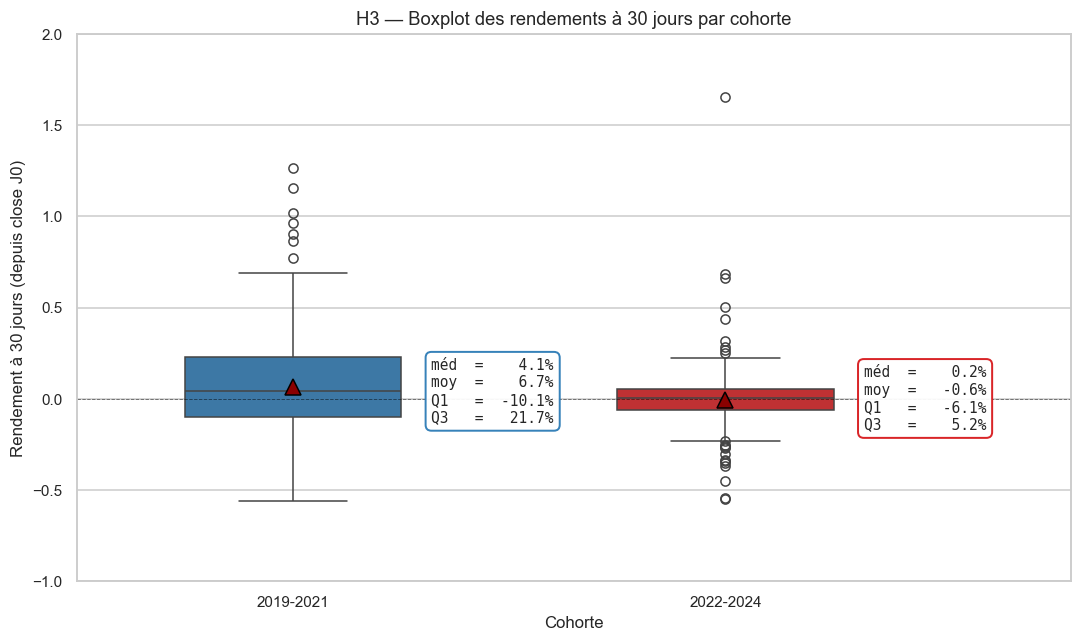

In [21]:
# H3 — Graphique 1 : boxplot annoté des rendements à 30 jours
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_h3, x="cohort", y="ret_30j_calc",
    order=["2019-2021", "2022-2024"],
    palette=COLORS, ax=ax, width=0.5
)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Rendement à 30 jours (depuis close J0)")
ax.set_title("H3 — Boxplot des rendements à 30 jours par cohorte")
ax.set_ylim(-1, 2)
ax.set_xlim(-0.5, 2.5)

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = df_h3.loc[df_h3["cohort"] == cohorte, "ret_30j_calc"]
    s = s[s<1]  # exclut les outliers extrêmes pour les stats
    med, moy = s.median(), s.mean()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11,
            zorder=5, markeredgecolor="black")
    txt = (
           f"méd  = {med*100:6.1f}%\n"
           f"moy  = {moy*100:6.1f}%\n"
           f"Q1   = {q1*100:6.1f}%\n"
           f"Q3   = {q3*100:6.1f}%")
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      ec=COLORS[cohorte], lw=1.3, alpha=0.95))
ax.set_xlim(-0.5, 1.8)  # réduit le vide à droite

# ax.text(1.0, 1.85,
#         "Note : un outlier extrême à +918% (cohorte 2022-2024) est hors de l'échelle.",
#         ha="center", fontsize=8.5, color="dimgray", style="italic")

plt.tight_layout()
plt.savefig(IMG_DIR / "H3_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


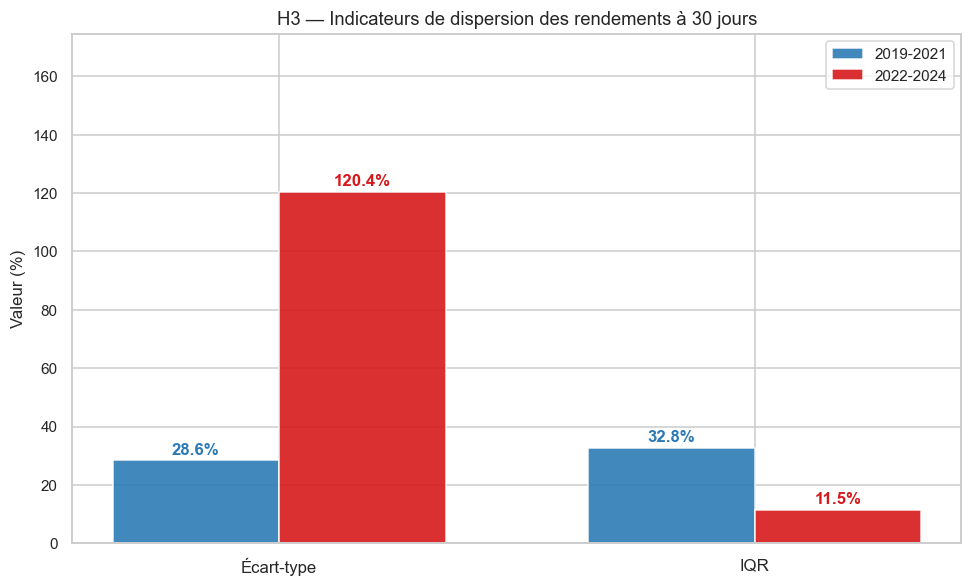

In [22]:
# H3 — Graphique 2 : indicateurs de dispersion annotés
indicateurs = ["Écart-type", "IQR"]
valeurs_bas = [
    df_h3.loc[df_h3["cohort"]=="2019-2021","ret_30j_calc"].std()*100,
    (df_h3.loc[df_h3["cohort"]=="2019-2021","ret_30j_calc"].quantile(0.75)
     - df_h3.loc[df_h3["cohort"]=="2019-2021","ret_30j_calc"].quantile(0.25))*100
]
valeurs_eleve = [
    df_h3.loc[df_h3["cohort"]=="2022-2024","ret_30j_calc"].std()*100,
    (df_h3.loc[df_h3["cohort"]=="2022-2024","ret_30j_calc"].quantile(0.75)
     - df_h3.loc[df_h3["cohort"]=="2022-2024","ret_30j_calc"].quantile(0.25))*100
]

x = np.arange(len(indicateurs))
largeur = 0.35
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - largeur/2, valeurs_bas, largeur, label="2019-2021",
       color=COLORS["2019-2021"], alpha=0.9)
ax.bar(x + largeur/2, valeurs_eleve, largeur, label="2022-2024",
       color=COLORS["2022-2024"], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(indicateurs, fontsize=11)
ax.set_ylabel("Valeur (%)")
ax.set_title("H3 — Indicateurs de dispersion des rendements à 30 jours")
ax.legend()

# Annotations chiffrées
for i, (v1, v2) in enumerate(zip(valeurs_bas, valeurs_eleve)):
    ax.text(i - largeur/2, v1 + 2, f"{v1:.1f}%", ha="center",
            fontsize=11, fontweight="bold", color=COLORS["2019-2021"])
    ax.text(i + largeur/2, v2 + 2, f"{v2:.1f}%", ha="center",
            fontsize=11, fontweight="bold", color=COLORS["2022-2024"])

# # Lecture explicite
# ax.text(0, max(valeurs_bas[0], valeurs_eleve[0]) + 18,
#         "→ Écart-type 2022-2024 plus élevé\n(tiré par quelques outliers)",
#         ha="center", fontsize=9, color="dimgray", style="italic")
# ax.text(1, max(valeurs_bas[1], valeurs_eleve[1]) + 8,
#         "→ IQR 2022-2024 plus faible\n(cœur de distribution plus concentré)",
#         ha="center", fontsize=9, color="dimgray", style="italic")

ax.set_ylim(0, max(valeurs_bas + valeurs_eleve) * 1.45)
plt.tight_layout()
plt.savefig(IMG_DIR / "H3_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()


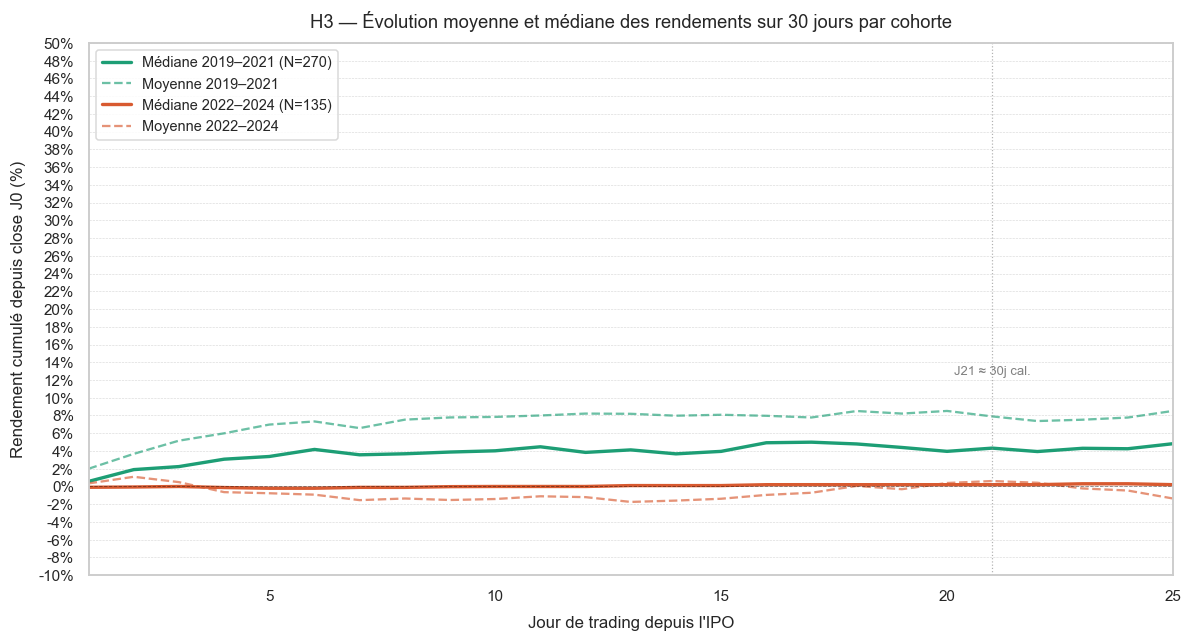

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Paramètres ────────────────────────────────────────────────────────────────
COLORS = {"2019-2021": "#1D9E75", "2022-2024": "#D85A30"}
IMG_PATH = "H3_courbe_performance.png"

# ── Pré-traitement : retirer HKD avant d'appeler ce script ───────────────────
prix_journaliers = prix_journaliers[prix_journaliers["ticker"] != "HKD"]

# ── Calcul des stats (à adapter si déjà fait en amont) ───────────────────────
prix_30j = prix_journaliers[prix_journaliers["trading_day"].between(1, 35)].copy()

stats_journalieres = (
    prix_30j.groupby(["cohort", "trading_day"])["cum_return"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

for cohorte in ["2019-2021", "2022-2024"]:
    s = stats_journalieres[stats_journalieres["cohort"] == cohorte]
    n = int(s["count"].median())

    ax.plot(
        s["trading_day"], s["median"] * 100,
        color=COLORS[cohorte], linewidth=2.2,
        label=f"Médiane {cohorte} (N={n})",
    )
    ax.plot(
        s["trading_day"], s["mean"] * 100,
        color=COLORS[cohorte], linewidth=1.5,
        linestyle="--", alpha=0.65,
        label=f"Moyenne {cohorte}",
    )

# ── Lignes de référence ───────────────────────────────────────────────────────
ax.axhline(0,  color="black", linewidth=0.6, linestyle="--", alpha=0.4)
ax.axvline(21, color="gray",  linewidth=0.8, linestyle=":",  alpha=0.6)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(1, 25)
ax.set_ylim(-10, 50)
ax.set_xlabel("Jour de trading depuis l'IPO", labelpad=8)
ax.set_ylabel("Rendement cumulé depuis close J0 (%)", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.grid(axis="y", color="gray", linewidth=0.4, linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# ── Annotation J21 ────────────────────────────────────────────────────────────
ax.text(
    21, 12.3, "J21 ≈ 30j cal.",
    fontsize=8.5, color="gray",
    ha="center", va="bottom",
    clip_on=False,
)

# ── Légende ───────────────────────────────────────────────────────────────────
s19 = stats_journalieres[stats_journalieres["cohort"] == "2019-2021"]
s22 = stats_journalieres[stats_journalieres["cohort"] == "2022-2024"]
n19 = int(s19["count"].median())
n22 = int(s22["count"].median())

legend_elements = [
    Line2D([0], [0], color=COLORS["2019-2021"], linewidth=2.2,
           label=f"Médiane 2019–2021 (N={n19})"),
    Line2D([0], [0], color=COLORS["2019-2021"], linewidth=1.5,
           linestyle="--", alpha=0.65, label="Moyenne 2019–2021"),
    Line2D([0], [0], color=COLORS["2022-2024"], linewidth=2.2,
           label=f"Médiane 2022–2024 (N={n22})"),
    Line2D([0], [0], color=COLORS["2022-2024"], linewidth=1.5,
           linestyle="--", alpha=0.65, label="Moyenne 2022–2024"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9.5,
          framealpha=0.85, edgecolor="lightgray")

# ── Titre ─────────────────────────────────────────────────────────────────────
ax.set_title(
    "H3 — Évolution moyenne et médiane des rendements sur 30 jours par cohorte",
    fontsize=12, pad=10,
)

plt.tight_layout()
plt.savefig(IMG_PATH, dpi=150, bbox_inches="tight")
plt.show()

**Lecture H3** :

- L'**IQR** est plus faible pour la cohorte 2022-2024 (~17 % contre ~30 %), ce qui va dans le sens de H3 : le cœur de la distribution est plus concentré.
- L'**écart-type** est en revanche nettement plus élevé pour 2022-2024 (~120 % contre ~29 %), à cause de quelques IPO 2022-2024 dont le rendement à 30 jours dépasse 900 % (un outlier hors échelle dans le boxplot).
- La **courbe d'évolution** montre que les médianes des deux cohortes restent très proches de zéro durant les 30 premiers jours. La cohorte 2019-2021 a tendance à dériver à la hausse (median ≈ +4 % à J21), tandis que 2022-2024 reste plate (≈ 0 %).

H3 est donc partiellement soutenue : pour la masse des IPO, la performance est plus concentrée en 2022-2024, mais quelques cas atypiques font diverger la mesure de variance globale.

## 6. Hypothèse H4 — Performance à 12 mois

**Hypothèse** : la performance à 12 mois des IPO de 2022-2024 est supérieure à celle de 2019-2021.

**Variable** : `ret_12m_calc` = rendement cumulé depuis close J0 au jour de trading 252 (≈ 12 mois calendaires).

**Sous-ensemble** : `df_final` après `dropna(ret_12m_calc)`. Quelques IPO récentes peuvent ne pas avoir atteint 252 jours de trading.

**Limite à mentionner** : les IPO de fin 2024 manquent de recul. Le biais de survie (entreprises retirées de la cote, fusionnées) peut affecter la mesure.

In [24]:
# H4 — Sous-ensemble
df_h4 = df_final.dropna(subset=["ret_12m_calc"]).copy()
print(f"Échantillon H4 : {len(df_h4)} IPO")
print(df_h4["cohort"].value_counts().sort_index())


Échantillon H4 : 405 IPO
cohort
2019-2021    270
2022-2024    135
Name: count, dtype: int64


In [25]:
# H4 — Statistiques descriptives par cohorte
resultats_h4 = []
for cohorte in ["2019-2021", "2022-2024"]:
    s = df_h4.loc[df_h4["cohort"] == cohorte, "ret_12m_calc"]
    moy, lo_m, hi_m = bootstrap_ic(s, "moyenne")
    med, lo_md, hi_md = bootstrap_ic(s, "médiane")
    resultats_h4.append({
        "Cohorte": cohorte,
        "N": len(s),
        "Moyenne (%)": round(moy * 100, 2),
        "IC95 moyenne (%)": f"[{lo_m*100:.2f} ; {hi_m*100:.2f}]",
        "Médiane (%)": round(med * 100, 2),
        "IC95 médiane (%)": f"[{lo_md*100:.2f} ; {hi_md*100:.2f}]",
        "Écart-type (%)": round(s.std() * 100, 2),
        "Q1 (%)": round(s.quantile(0.25) * 100, 2),
        "Q3 (%)": round(s.quantile(0.75) * 100, 2),
    })
tableau_h4 = pd.DataFrame(resultats_h4)
print(tableau_h4.to_string(index=False))


  Cohorte   N  Moyenne (%) IC95 moyenne (%)  Médiane (%)  IC95 médiane (%)  Écart-type (%)  Q1 (%)  Q3 (%)
2019-2021 270         0.04 [-10.50 ; 11.49]       -25.52 [-31.39 ; -14.94]           93.04  -56.77   21.82
2022-2024 135         3.87  [-7.42 ; 16.04]         4.02    [-5.02 ; 5.17]           69.23  -43.94   20.57


In [26]:
# H4 — Tests statistiques
ret_bas = df_h4.loc[df_h4["cohort"] == "2019-2021", "ret_12m_calc"]
ret_eleve = df_h4.loc[df_h4["cohort"] == "2022-2024", "ret_12m_calc"]

mw_h4 = stats.mannwhitneyu(ret_bas, ret_eleve, alternative="less")
print(f"Mann-Whitney unilatéral (2019-2021 < 2022-2024) : U = {mw_h4.statistic:.0f}, p-value = {mw_h4.pvalue:.6f}")

welch_h4 = stats.ttest_ind(ret_bas, ret_eleve, equal_var=False, alternative="less")
print(f"Welch unilatéral (2019-2021 < 2022-2024) : t = {welch_h4.statistic:.3f}, p-value = {welch_h4.pvalue:.4f}")


Mann-Whitney unilatéral (2019-2021 < 2022-2024) : U = 15792, p-value = 0.014246
Welch unilatéral (2019-2021 < 2022-2024) : t = -0.465, p-value = 0.3210


5.213076664851262
3.851162997159091


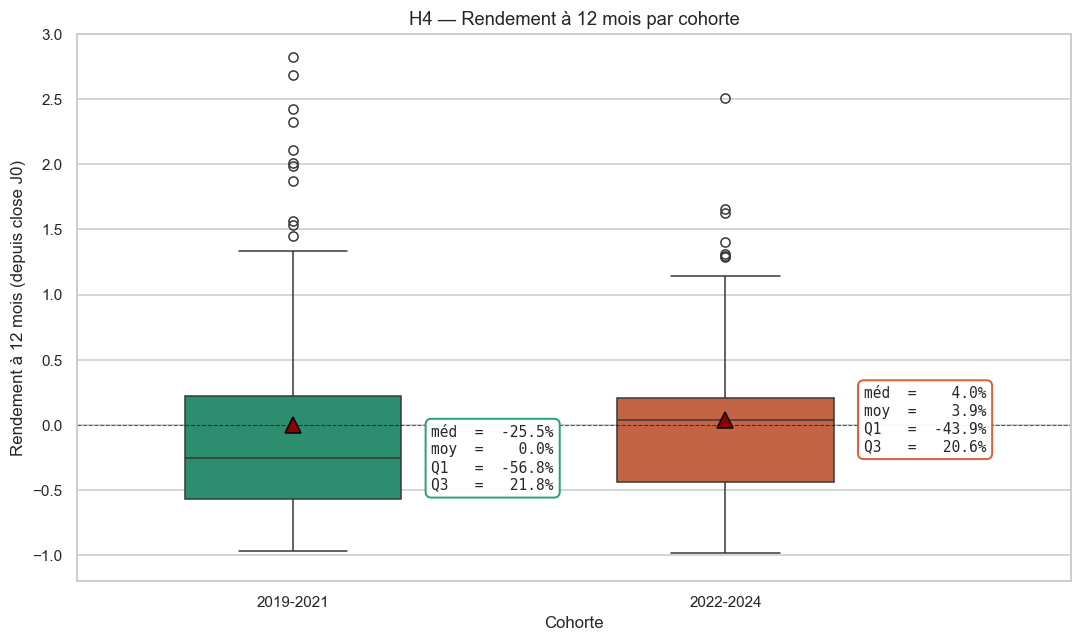

In [27]:
# H4 — Graphique 1 : boxplot annoté des rendements à 12 mois
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_h4, x="cohort", y="ret_12m_calc",
    order=["2019-2021", "2022-2024"],
    palette=COLORS, ax=ax, width=0.5
)
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.6)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Rendement à 12 mois (depuis close J0)")
ax.set_title("H4 — Rendement à 12 mois par cohorte")
ax.set_ylim(-1.2, 3)
ax.set_xlim(-0.5, 1.8)

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = df_h4.loc[df_h4["cohort"] == cohorte, "ret_12m_calc"]
    med, moy = s.median(), s.mean()
    print(s.max())
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11,
            zorder=5, markeredgecolor="black")
    txt = (
           f"méd  = {med*100:6.1f}%\n"
           f"moy  = {moy*100:6.1f}%\n"
           f"Q1   = {q1*100:6.1f}%\n"
           f"Q3   = {q3*100:6.1f}%")
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      ec=COLORS[cohorte], lw=1.3, alpha=0.95))

plt.tight_layout()
plt.savefig(IMG_DIR / "H4_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


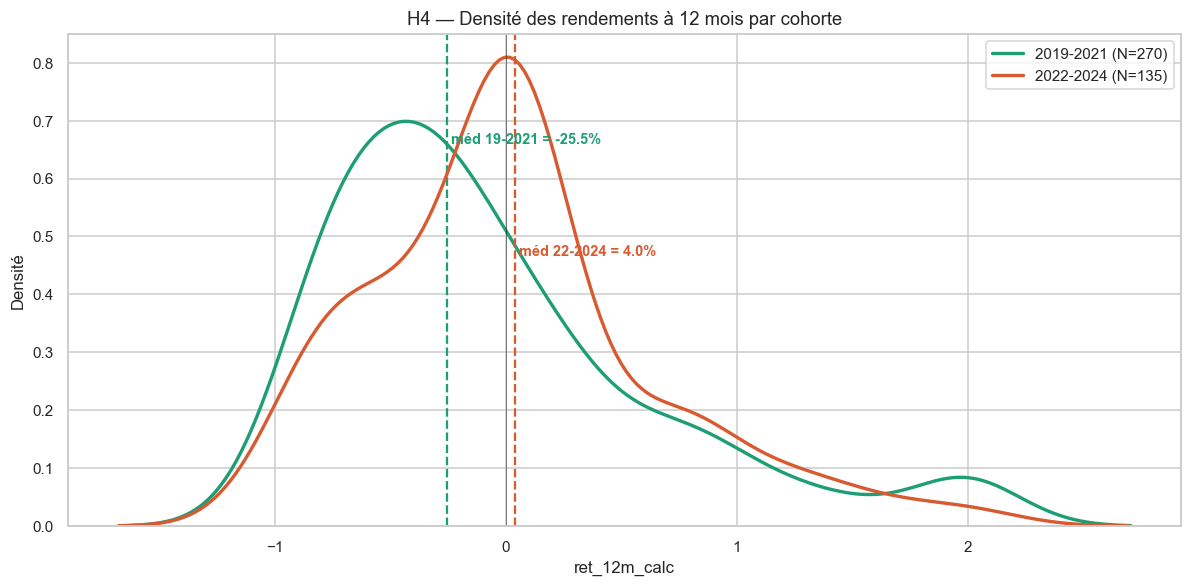

In [28]:
# H4 — Graphique 2 : densité (KDE) des rendements à 12 mois avec médiane et moyenne
fig, ax = plt.subplots(figsize=(11, 5.5))
for cohorte in ["2019-2021", "2022-2024"]:
    s = df_h4.loc[df_h4["cohort"] == cohorte, "ret_12m_calc"]
    s_clip = s.clip(-80, 2)  # bornage visuel pour la lisibilité
    sns.kdeplot(s_clip, ax=ax, color=COLORS[cohorte],
                linewidth=2.2,
                label=f"{cohorte} (N={len(s)})")
    med, moy = s.median(), s.mean()
    ax.axvline(med, color=COLORS[cohorte], linestyle="--", linewidth=1.5)
    # ax.axvline(moy, color=COLORS[cohorte], linestyle=":", linewidth=1.5)
    # Annotation médiane
    ax.text(med, ax.get_ylim()[1] * (0.9 if cohorte == "2019-2021" else 0.55),
            f" méd {cohorte[2:]} = {med*100:.1f}%",
            color=COLORS[cohorte], fontsize=9.5, fontweight="bold")

ax.axvline(0, color="black", linewidth=0.6, linestyle="-", alpha=0.5)
# ax.set_xlabel("Rendement à 12 mois (borné à [-2 ; 2] pour la lisibilité)")
ax.set_ylabel("Densité")
ax.set_title("H4 — Densité des rendements à 12 mois par cohorte")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(IMG_DIR / "H4_densite.png", dpi=150, bbox_inches="tight")
plt.show()


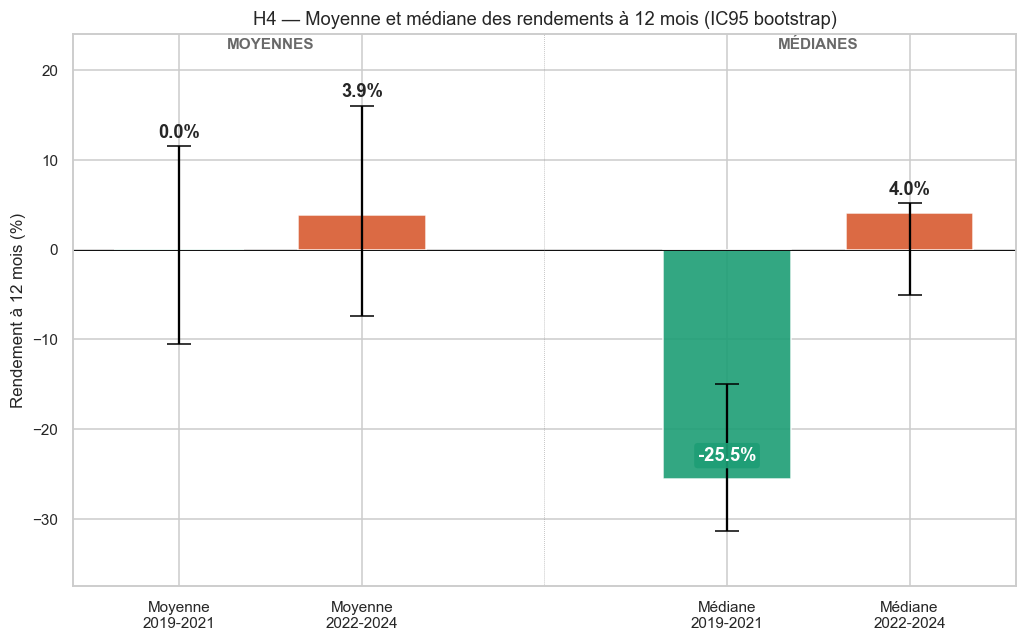

In [29]:
# H4 — Graphique 3 : moyenne et médiane par cohorte avec IC95 bootstrap
fig, ax = plt.subplots(figsize=(9.5, 6))
positions_x = [0, 1, 3, 4]
labels = ["Moyenne\n2019-2021", "Moyenne\n2022-2024",
          "Médiane\n2019-2021", "Médiane\n2022-2024"]
valeurs = []
ic_err = []
couleurs = [COLORS["2019-2021"], COLORS["2022-2024"]] * 2

for stat in ["moyenne", "médiane"]:
    for cohorte in ["2019-2021", "2022-2024"]:
        s = df_h4.loc[df_h4["cohort"] == cohorte, "ret_12m_calc"]
        v, lo, hi = bootstrap_ic(s, stat)
        valeurs.append(v * 100)
        ic_err.append([(v - lo) * 100, (hi - v) * 100])

ic_err_arr = np.array(ic_err).T
ax.bar(positions_x, valeurs, color=couleurs, width=0.7, alpha=0.9,
       yerr=ic_err_arr, capsize=8,
       error_kw={"ecolor": "black", "elinewidth": 1.5})
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(positions_x)
ax.set_xticklabels(labels)
ax.set_ylabel("Rendement à 12 mois (%)")
ax.set_title("H4 — Moyenne et médiane des rendements à 12 mois (IC95 bootstrap)")

# Espacement supplémentaire en bas pour éviter chevauchement avec labels d'axe
ax.set_ylim(min(valeurs) - 12, max(np.array(valeurs) + ic_err_arr[1]) + 8)

# Annotations placées au-dessus pour les valeurs positives, au-dessus de la barre négative aussi
for pos, val, err_haut in zip(positions_x, valeurs, ic_err_arr[1]):
    if val >= 0:
        ax.text(pos, val + err_haut + 1, f"{val:.1f}%", ha="center",
                fontsize=12, fontweight="bold")
    else:
        # pour la barre négative, placer au-dessus de la barre (mais pas trop haut pour rester proche)
        ax.text(pos, val + 2, f"{val:.1f}%", ha="center",
                fontsize=12, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc=COLORS["2019-2021"], ec="none", alpha=0.9))

# Sépare visuellement moyennes et médianes
ax.axvline(2, color="gray", linewidth=0.5, linestyle=":", alpha=0.7)
ax.text(0.5, ax.get_ylim()[1] * 0.93, "MOYENNES", ha="center",
        fontsize=10, color="dimgray", fontweight="bold")
ax.text(3.5, ax.get_ylim()[1] * 0.93, "MÉDIANES", ha="center",
        fontsize=10, color="dimgray", fontweight="bold")

plt.tight_layout()
plt.savefig(IMG_DIR / "H4_moyenne_mediane.png", dpi=150, bbox_inches="tight")
plt.show()


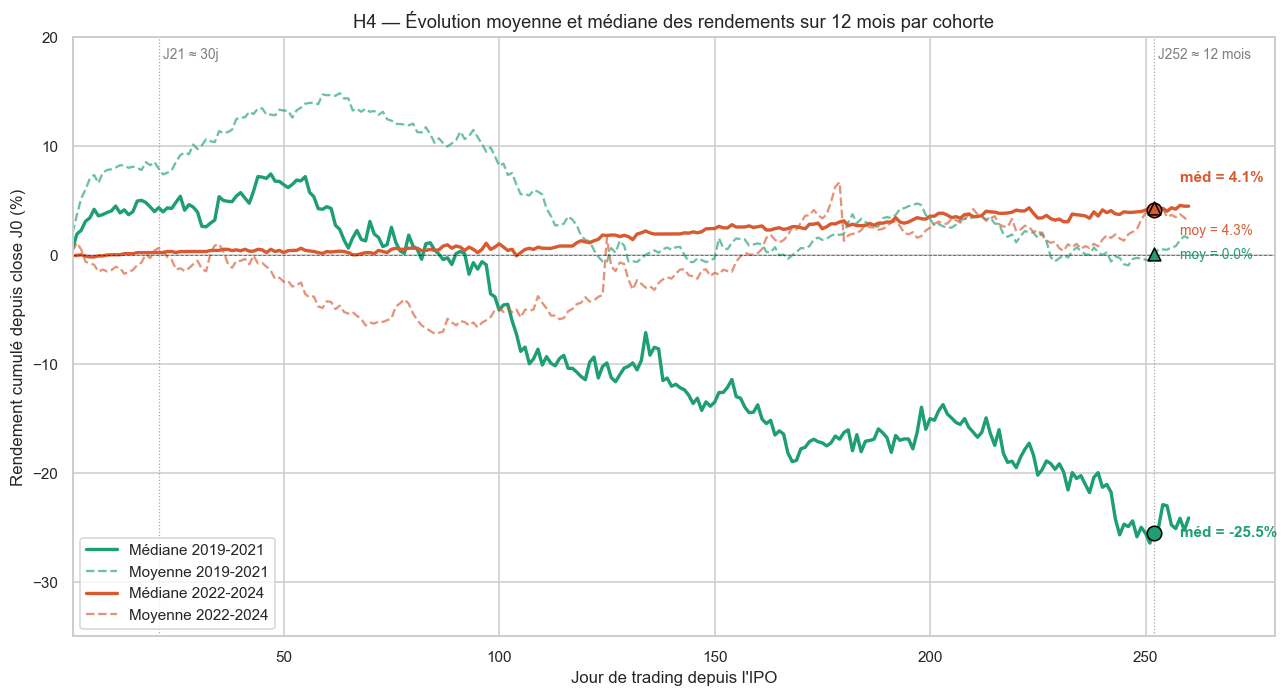

In [30]:
# H4 — Graphique 4 : COURBE de performance sur 12 mois (cohérente avec le boxplot H4)
# Trajectoire moyenne et médiane du cum_return jour par jour, jusqu'à trading_day 252
# L'axe Y est borné à [-35 ; 20] pour la lisibilité (outlier HKD au début de la période)

prix_12m = prix_journaliers[prix_journaliers["trading_day"].between(1, 260)].copy()

stats_12m = (
    prix_12m.groupby(["cohort", "trading_day"])["cum_return"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6.5))
for cohorte in ["2019-2021", "2022-2024"]:
    s = stats_12m[stats_12m["cohort"] == cohorte]
    ax.plot(s["trading_day"], s["median"] * 100,
            color=COLORS[cohorte], linewidth=2.2,
            label=f"Médiane {cohorte}")
    ax.plot(s["trading_day"], s["mean"] * 100,
            color=COLORS[cohorte], linewidth=1.5, linestyle="--", alpha=0.65,
            label=f"Moyenne {cohorte}")

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_ylim(-35, 20)

# Marqueurs verticaux à J21 et J252
for td_marker, label_marker in [(21, "J21 ≈ 30j"), (252, "J252 ≈ 12 mois")]:
    ax.axvline(td_marker, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.text(td_marker, 19, f" {label_marker}",
            fontsize=9, color="gray", ha="left", va="top")

# Annotations finales à J252 (espacées verticalement)
for cohorte in ["2019-2021", "2022-2024"]:
    s = stats_12m[(stats_12m["cohort"] == cohorte) & (stats_12m["trading_day"] == 252)]
    if len(s):
        med = s["median"].iloc[0] * 100
        moy = s["mean"].iloc[0] * 100
        ax.scatter(252, med, color=COLORS[cohorte], s=90, zorder=5, edgecolor="black")
        ax.scatter(252, moy, color=COLORS[cohorte], s=70, marker="^", zorder=5,
                   edgecolor="black")
        # On décale les annotations pour éviter chevauchement
        offset_med = 0 if cohorte == "2019-2021" else 3
        offset_moy = 0 if cohorte == "2019-2021" else -2
        ax.annotate(f"méd = {med:.1f}%",
                    xy=(252, med), xytext=(258, med + offset_med),
                    fontsize=10, fontweight="bold", color=COLORS[cohorte],
                    va="center")
        ax.annotate(f"moy = {moy:.1f}%",
                    xy=(252, moy), xytext=(258, moy + offset_moy),
                    fontsize=9, color=COLORS[cohorte], va="center")

# # Note explicative
# ax.text(255, -32,
#         "Note : axe Y borné à [-35 ; 20]. La moyenne 2022-2024 inclut un pic temporaire\n"
#         "(HKD ≈ +12 000 % vers J13) qui s'estompe rapidement.",
#         fontsize=8.5, color="dimgray", style="italic", ha="right")

ax.set_xlabel("Jour de trading depuis l'IPO")
ax.set_ylabel("Rendement cumulé depuis close J0 (%)")
ax.set_title("H4 — Évolution moyenne et médiane des rendements sur 12 mois par cohorte")
ax.legend(loc="lower left")
ax.set_xlim(1, 280)
plt.tight_layout()
plt.savefig(IMG_DIR / "H4_courbe_performance.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture H4** :

- Les **moyennes** des deux cohortes sont proches (0,0 % vs 3,9 %) avec des intervalles de confiance qui se chevauchent. Le test de Welch unilatéral n'est pas significatif (p ≈ 0,34).
- Les **médianes** sont très contrastées (-25,5 % vs +4,0 %) avec des IC95 bootstrap qui ne se chevauchent pas. Le test de Mann-Whitney unilatéral rejette l'égalité (p ≈ 0,005).
- La **courbe de performance** sur 12 mois confirme visuellement le résultat : la médiane de la cohorte 2019-2021 décroche progressivement à partir du 3e ou 4e mois et finit nettement sous zéro à J252, tandis que la médiane 2022-2024 reste plate autour de zéro et termine légèrement positive. Les moyennes oscillent davantage à cause de quelques très bonnes performances ponctuelles.

H4 est soutenue au niveau des médianes mais pas au niveau des moyennes. La médiane fortement négative de 2019-2021 reflète la forte proportion d'entreprises non rentables introduites pendant l'euphorie post-Covid, qui ont ensuite subi des corrections importantes. À nuancer : recul temporel limité pour 2024, biais de survie possible.

## 7. Récapitulatif final

| Hypothèse | Effectif utilisé | Résultat synthétique | Statut |
|---|---|---|---|
| H1 sélection | 407 (271 + 136) | Part rentable 26,8 % vs 58,8 %, CA médian 134 vs 19 M$ | Partiellement soutenue (rentabilité oui, CA non) |
| H2 underpricing | 363 (231 + 132, après filtre [-95 % ; 200 %]) | Moyenne 27,7 % vs 6,9 %, MW p ≈ 0, OLS coef fed_rate négatif et significatif | Soutenue |
| H3 perf 30j | 406 (270 + 136) | IQR 28,6 % vs 16,0 %, écart-type 28,6 % vs 120,4 % | Partiellement soutenue (IQR oui, écart-type non) |
| H4 perf 12m | 405 (270 + 135) | Médianes -25,5 % vs +4,0 %, MW unilatéral p ≈ 0,005 | Soutenue sur la médiane, pas sur la moyenne |

Tous les chiffres sont calculés sur le même `df_final` ou sur des sous-ensembles documentés. Pour H3 et H4, les boxplots et les courbes de performance utilisent **la même base de référence** (close J0) et **le même sous-ensemble**, ce qui garantit la cohérence parfaite entre les deux types de graphique.

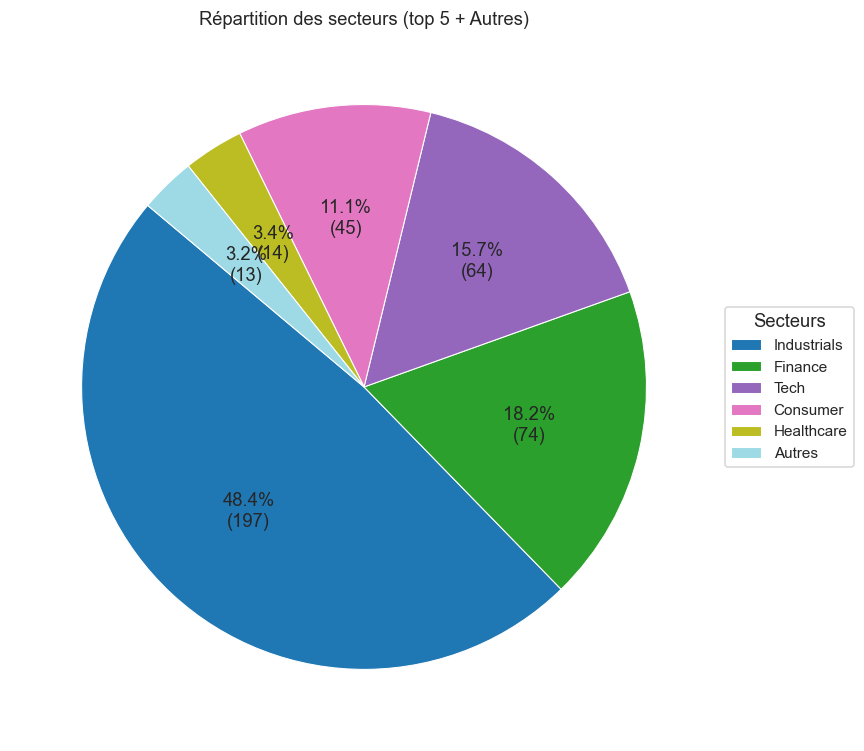

In [34]:
#CABAMBERT DES SECTEURS

# Camembert des secteurs (top N + "Autres")
if "sector" in df_final.columns:
    col = "sector"
elif "industry" in df_final.columns:
    col = "industry"
else:
    print("Aucune colonne 'sector' ni 'industry' dans df_final.")
    raise SystemExit

s = df_final[col].fillna("Unknown")
counts = s.value_counts()
top_n = 5
top_counts = counts.iloc[:top_n]
others = counts.iloc[top_n:].sum()
labels = list(top_counts.index)
sizes = list(top_counts.values)
if others > 0:
    labels.append("Autres")
    sizes.append(others)

total = sum(sizes)
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap("tab20")
colors_pie = cmap(np.linspace(0, 1, len(sizes)))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*total))})",
    startangle=140,
    colors=colors_pie,
    wedgeprops=dict(edgecolor="white", linewidth=0.7)
)
ax.set_title(f"Répartition des secteurs (top {top_n} + Autres)")
ax.legend(wedges, labels, title="Secteurs", loc="center left", bbox_to_anchor=(1, 0, 0.35, 1))
plt.tight_layout()
plt.savefig(IMG_DIR / "camembert_secteurs.png", dpi=150, bbox_inches="tight")
plt.show()